In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
plt.style.use('default')
import matplotlib
import pandas as pd
import os
import re
from tqdm import tqdm
color_array=np.linspace(0,1,11)
cmap = plt.cm.tab20b
filename = 'g4simple_out_nt_g4sntuple.csv'

In [2]:
# Skip the initial rows that do not contain data
skip_rows = 24  # Adjust based on your file's header lines
r_min = 0 
r_max = 100 #34.5 
# Define column names as they appear in your CSV file
column_names = ['nEvents', 'event', 'pid', 'trackID', 'parentID', 'step', 'KE', 'Edep', 'x', 'y', 'z', 'lx', 'ly', 'lz', 'pdx', 'pdy', 'pdz', 't', 'volID', 'iRep']

# Load the data, skipping the header rows and assigning column names
data = pd.read_csv(filename, skiprows=skip_rows, header=None, names=column_names)
# Filter for hits where energy was deposited in the detector volume
detector_hits = data.loc[(data['Edep']>0) & (data['volID'] == 1) & ((data['x']**2 + data['y']**2)**0.5<r_max)]

# Process the DataFrame to match the required structure
proc_df = detector_hits.rename(columns={'iRep': 'detID', 'Edep': 'edep'}).copy()
proc_df['edep'] *= 1000  # Convert 'edep' to keV
proc_df['z_hit'] = abs(proc_df['z'] - round(proc_df['z'].min(), 2))  # Adjust 'z_hit' if needed
proc_df['e_total'] = proc_df.groupby('event')['edep'].transform('sum')  # Calculate total deposited energy per event

# Select and rename columns to match the expected output structure
proc_df = proc_df[['event', 'x', 'y', 'z_hit', 'edep', 'volID', 'detID', 'e_total']]
proc_df.rename(columns={'x': 'x_hit', 'y': 'y_hit'}, inplace=True)

proc_df['r_hit'] = ((proc_df['x_hit']**2 + proc_df['y_hit']**2)**0.5)#.round(5)

In [3]:
field_dir = '/work/users/k/b/kbhimani/EH-Drift_data/fields/'
det='ponama_1' #'ponama_1' 'V07647A' 

Minimum z with field > 0: 0.0
Radial range at z_min with field > 0: 1.4 - 30.0
Filtered proc_df has 32848 rows within radial range 1.4 - 30.0.


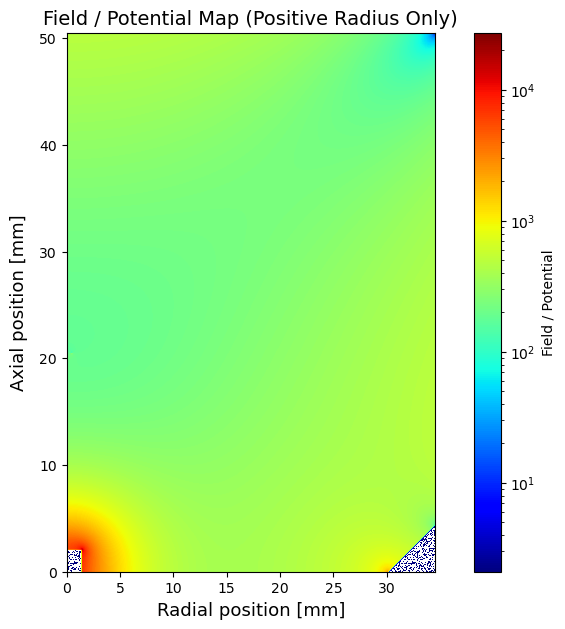

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Step 1: Load field data
data = np.loadtxt(field_dir + f'ev_fin_{det}_grid=0.0200_sc=-0.3000.dat')
r = np.unique(data[:, 0])  # Unique radial positions
z = np.unique(data[:, 1])  # Unique axial positions
field_values = data[:, 3]  # Field or potential values

field_vals = field_values.reshape(len(r), len(z))
field_vals[field_vals < 0] = 0  # Set negative values to 0

# Step 2: Find minimum z and corresponding r values where field > 0
valid_indices = np.where(data[:, 3] > 0)  # Indices where field > 0
r_valid = data[valid_indices, 0].flatten()  # Radial positions where field > 0
z_valid = data[valid_indices, 1].flatten()  # Axial positions where field > 0

# Identify the minimum z among valid points
z_min = z_valid.min()

# Get r values corresponding to the minimum z
z_min_indices = np.where((data[:, 1] == z_min) & (data[:, 3] > 0))
r_at_z_min = data[z_min_indices, 0].flatten()  # Radial values at z_min where field > 0

# Calculate r_min and r_max
r_min, r_max = r_at_z_min.min(), r_at_z_min.max()

print(f"Minimum z with field > 0: {z_min}")
print(f"Radial range at z_min with field > 0: {r_min} - {r_max}")

# Step 3: Filter proc_df based on r_min and r_max
proc_df = proc_df[(proc_df['r_hit'] >= r_min) & (proc_df['r_hit'] <= r_max)]

print(f"Filtered proc_df has {len(proc_df)} rows within radial range {r_min} - {r_max}.")

# Step 4: Visualize the field values for positive radial side
bounds = (min(r), max(r), min(z), max(z))
fig = plt.figure(figsize=(10, 7))
ip = plt.imshow(field_vals.T, norm=colors.LogNorm(),
                extent=bounds,  # Boundaries of the edges of the 'image' data
                origin="lower",  # Origin at the bottom-left
                cmap='jet')  # Use 'jet' colormap
plt.xlabel("Radial position [mm]", size=13)
plt.ylabel("Axial position [mm]", labelpad=8, size=13)
plt.colorbar(label="Field / Potential")
plt.title("Field / Potential Map (Positive Radius Only)", size=14)
plt.show()


Text(0.5, 0, 'X hit (mm)')

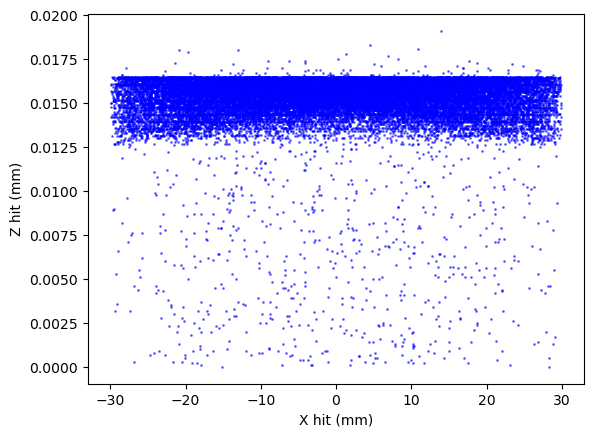

In [5]:
plt.plot(proc_df['x_hit'], proc_df['z_hit'],'bo', markersize=1, alpha=0.5)
plt.ylabel('Z hit (mm)')
plt.xlabel('X hit (mm)')

Text(0.5, 0, 'X (mm)')

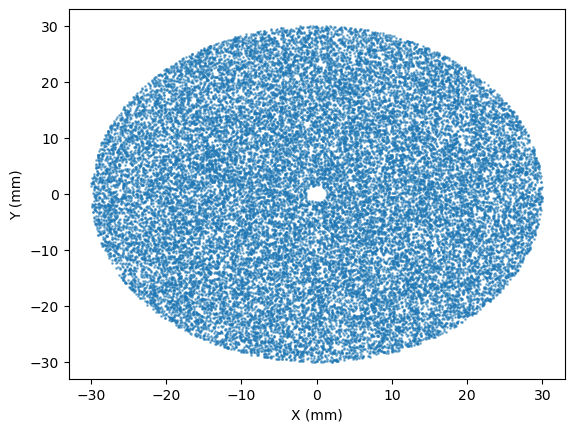

In [6]:
plt.scatter(proc_df['x_hit'], proc_df['y_hit'], alpha=0.5, s=1)
plt.ylabel('Y (mm)')
plt.xlabel('X (mm)')

Text(0.5, 0, 'Radius (mm)')

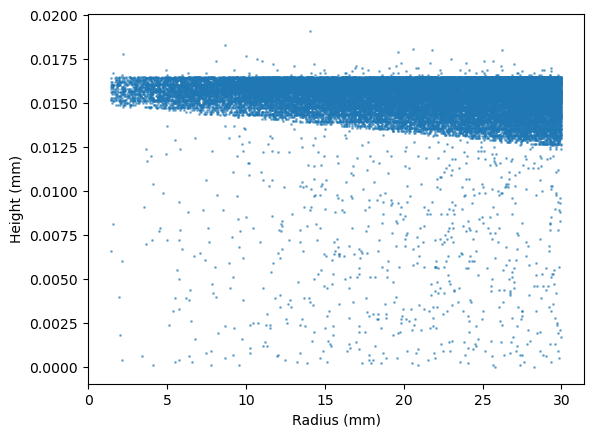

In [7]:
plt.scatter(proc_df['r_hit'],proc_df['z_hit'], alpha=0.5, s=1)
plt.ylabel('Height (mm)')
plt.xlabel('Radius (mm)')

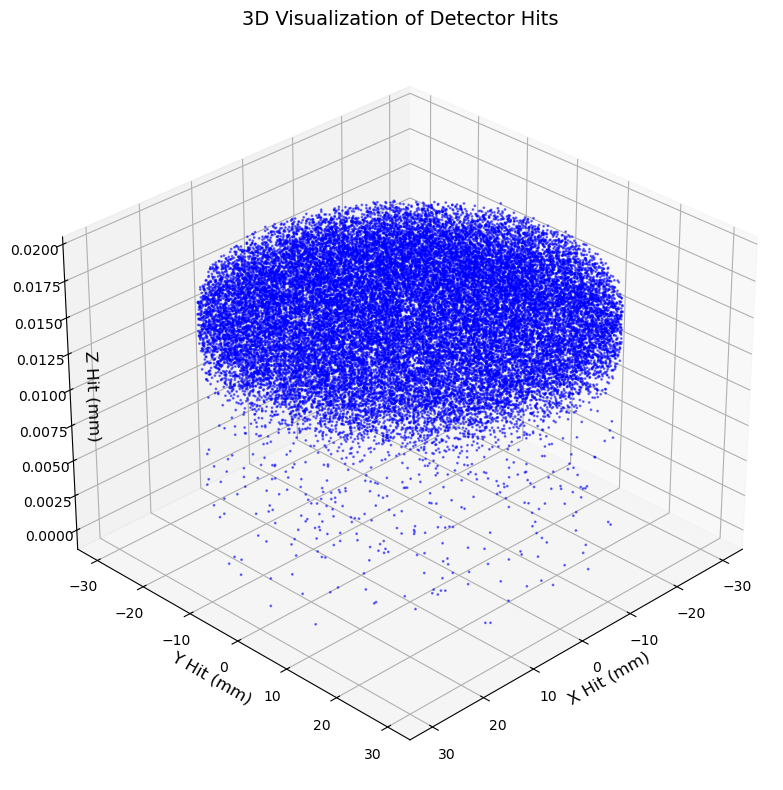

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data
ax.scatter(
    proc_df['x_hit'], 
    proc_df['y_hit'], 
    proc_df['z_hit'], 
    s=1, alpha=0.5, c='b'
)

# Set axis labels
ax.set_xlabel('X Hit (mm)', fontsize=12, labelpad=0) 
ax.set_ylabel('Y Hit (mm)', fontsize=12, labelpad=0)
ax.set_zlabel('Z Hit (mm)', fontsize=12, labelpad=-30)
ax.set_title('3D Visualization of Detector Hits', fontsize=14)

# Adjust the view angle
ax.view_init(elev=30, azim=45)

# Automatically adjust layout
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'G4 Simple Output Energy Spectrum')

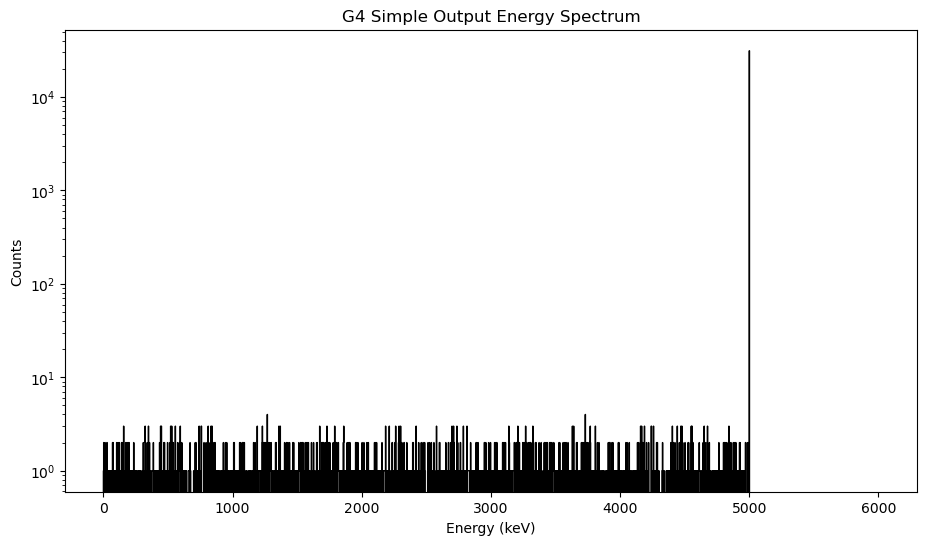

In [9]:
plt.figure(figsize=(11, 6))
hist, bins, _ = plt.hist(proc_df['edep'], bins=3000, range=(0, 6000), histtype='step', color='k')
plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.title('G4 Simple Output Energy Spectrum')

100%|██████████| 1/1 [00:04<00:00,  4.42s/it]


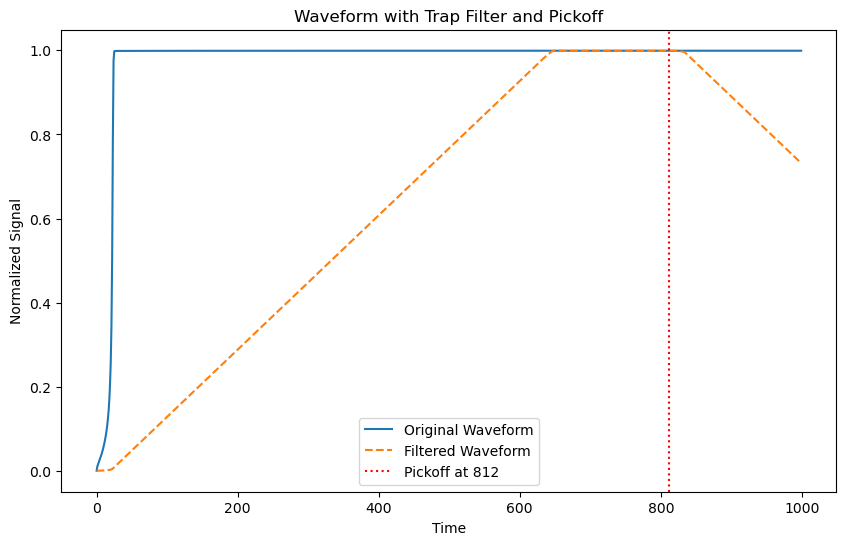

Index(['r', 'z', 'eng', 'sc', 'sf_drift', 'grid', 'pass_thickness',
       'self_repulsion', 'det', 'wf', 'energy_estimate'],
      dtype='object')


In [10]:
# directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{detector}'
import sys
sys.path.append('/nas/longleaf/home/kbhimani/EH-Drift/Analysis')

from tools import (
    load_waveform_data,
    compute_pickoff_values_and_plot_random,
    add_tail_slope_to_dataframe,
    calculate_tail_slope,
    query_and_plot_waveform
)

# directory = '/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/'
# detector = 'ponama_1' # old panoma
# sim_time=8000
# step_time_out = 10
# rise = 4000 
# flat = 3000
# pickoff = 7000

directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{det}'
detector = 'ponama_1' # 'ICPC' 'P42575A' 'UNC_scanner' 'ponama_1' 'V00048A' 'P00749A' 'P00661B'
sim_time=16000
step_time_out = 16
rise = 10000 
flat = 3000
pickoff = 13000
waveforms_df = load_waveform_data(directory)
activeness = compute_pickoff_values_and_plot_random(waveforms_df, rise_samp := math.floor(rise/step_time_out), flat_samp := math.floor(flat/step_time_out), pickoff_samp := math.floor(pickoff/step_time_out), plot_random=True)

print(waveforms_df.columns)
# waveforms_df = waveforms_df[waveforms_df['r']>2]

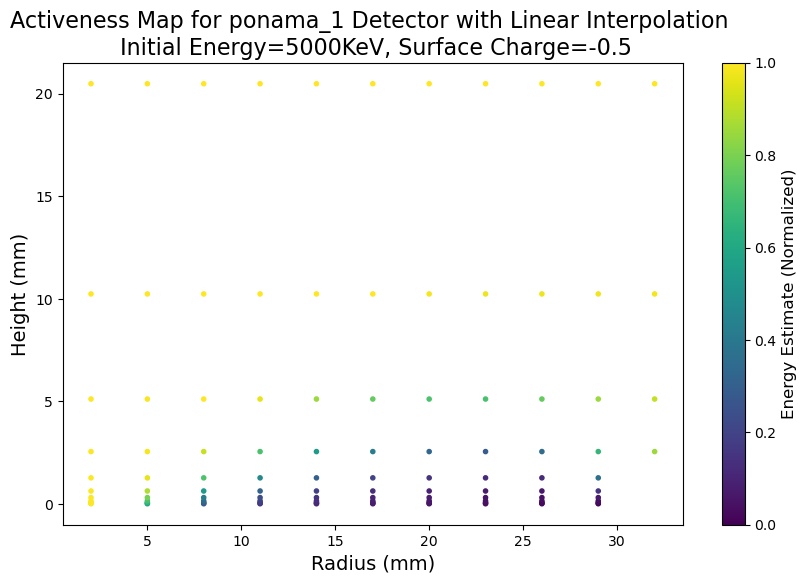

In [20]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

# Filter parameters
filter_det = detector
filter_sc = -0.5
filter_eng = 5000 
filter_sd = 0.001
v_min=0
v_max=1
# Apply filter to DataFrame
filtered_df = waveforms_df[
    (waveforms_df['det'] == filter_det) & 
    (waveforms_df['sc'] == filter_sc) & 
    (waveforms_df['eng'] == filter_eng) &
    (waveforms_df['sf_drift'] == filter_sd)
]

# Extracting r, z, and energy estimate for plotting
r_plot = filtered_df['r'].to_numpy()
z_plot = filtered_df['z'].to_numpy()
energy_estimate = filtered_df['energy_estimate'].to_numpy()  # Adjust this if 'energy_estimate' is not the correct column

# Ensure all energy_estimate values are within the range 0 to 1
energy_estimate = np.clip(energy_estimate, 0, 1)

# Create scatter plot
plt.figure(figsize=(10, 6))
sc = plt.scatter(r_plot, z_plot, c=energy_estimate, cmap=cm.viridis, s=9, vmin=v_min, vmax=v_max)  # Fixed color scale
cbar = plt.colorbar(sc)
cbar.set_label('Energy Estimate (Normalized)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.xlabel('Radius (mm)', fontsize=14)
plt.ylabel('Height (mm)', fontsize=14)
plt.title(f'Activeness Map for {filter_det} Detector with Linear Interpolation \n Initial Energy={filter_eng}KeV, Surface Charge={filter_sc}', fontsize=16)

# Optional: Set specific limits for x and y axes
# plt.xlim(xmin, xmax)
# plt.ylim(ymin, ymax)

# Save the plot, if needed
# plt.savefig("path/to/save/your/plot.png", dpi=100)

# Display the plot
plt.show()


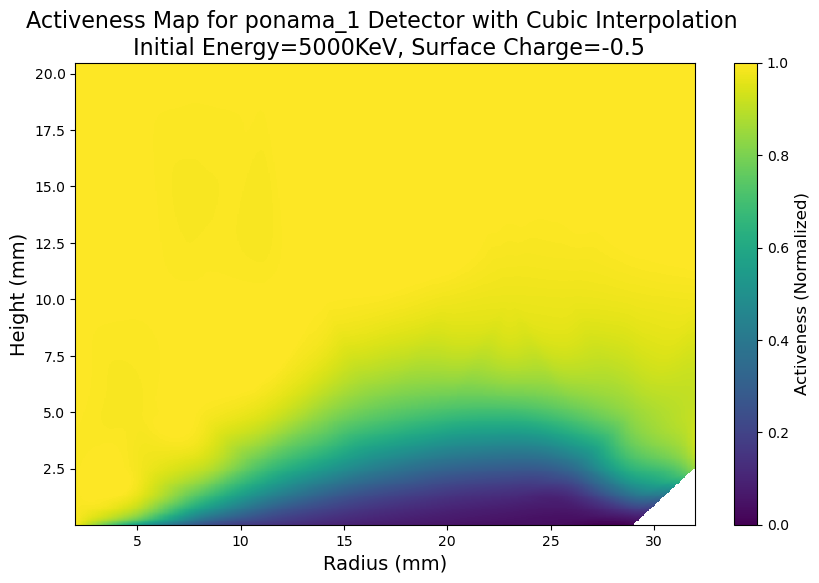

In [21]:
from scipy.interpolate import griddata
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

# Define grid size
grid_size = 500

# Apply filter to DataFrame
filtered_df = waveforms_df[
    (waveforms_df['det'] == filter_det) & 
    (waveforms_df['sc'] == filter_sc) & 
    (waveforms_df['eng'] == filter_eng) &
    (waveforms_df['sf_drift'] == filter_sd)
]

# Extracting r, z, and energy estimate for plotting
r_plot = filtered_df['r'].to_numpy()
z_plot = filtered_df['z'].to_numpy()
energy_estimate = filtered_df['energy_estimate'].to_numpy()  # Adjust this if 'wf' is not the correct column for energy estimate

# Create a grid for interpolation
r_lin = np.linspace(r_plot.min(), r_plot.max(), grid_size)
z_lin = np.linspace(z_plot.min(), z_plot.max(), grid_size)
r_grid, z_grid = np.meshgrid(r_lin, z_lin)

# Interpolate the data using 'cubic' method
energy_interp = griddata((r_plot, z_plot), energy_estimate, (r_grid, z_grid), method='cubic')

# Adjust the dimensions of energy_interp to fit the grid
energy_interp_adjusted = energy_interp[:-1, :-1]

# Clip energy estimates to range 0 to 1
energy_interp_clipped = np.clip(energy_interp_adjusted, 0, 1)

# Create heatmap
plt.figure(figsize=(10, 6))
heatmap = plt.pcolormesh(r_grid[:-1, :-1], z_grid[:-1, :-1], energy_interp_clipped, cmap=cm.viridis, shading='auto', vmin=v_min, vmax=v_max)  # Fixed color scale
cbar = plt.colorbar(heatmap)
cbar.set_label('Activeness (Normalized)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.xlabel('Radius (mm)', fontsize=14)
plt.ylabel('Height (mm)', fontsize=14)
plt.title(f'Activeness Map for {filter_det} Detector with Cubic Interpolation \n Initial Energy={filter_eng}KeV, Surface Charge={filter_sc}', fontsize=16)

# Optional: Overlay excluded areas as white rectangles
# excluded_areas = [((17,a 0.), (25, 2.0))]  # Define excluded areas as ((r_start, z_start), (r_end, z_end))
# for (r_start, z_start), (r_end, z_end) in excluded_areas:
#     plt.gca().add_patch(Rectangle((r_start, z_start), r_end-r_start, z_end-z_start, color='white', zorder=2))

plt.xlim([r_plot.min(), r_plot.max()])
plt.ylim([z_plot.min(), z_plot.max()])

# Save the plot, if needed
# plt.savefig(f"figs/deadness_test{filter_det}_{filter_eng}_{filter_sc}_cubic_fit.pdf", dpi=100)

# Display the plot
plt.show()


We load and interpolate the data for activenss with the code above. The activeness is the fraction of the energy we expect to collect. So for each event and each deposition we want to multiply the energy with the activeness at that point so for each edep r_e, z_e we multiply by closest activeness (r_e,z_e) at that point. to esure that we can find the edep point in the map, round all values in the hits to 4 digits and make sure the interpolated map is find enough to match that

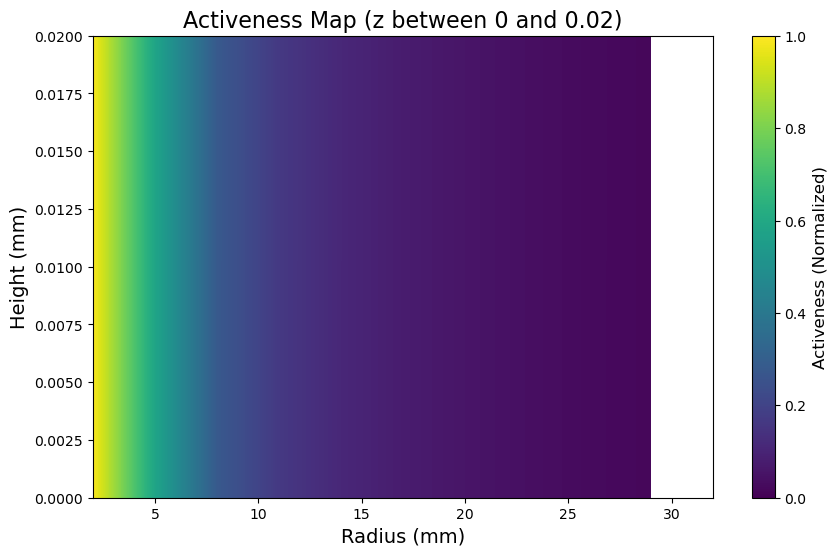

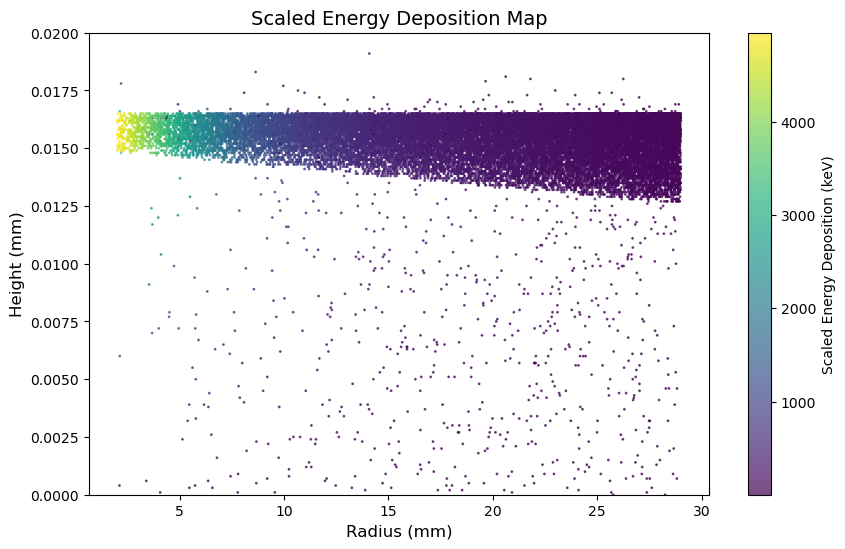

In [22]:
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# Step 1: Add z=0.00 with same activeness as z=0.02 for all unique r
def adjust_activeness_map(waveforms_df):
    """
    Adjust the activeness map by adding points at z=0.00 for all unique r
    with the same values as at z=0.02.
    """
    z_0_02_points = waveforms_df[waveforms_df['z'] == 0.02].copy()
    z_0_02_points['z'] = 0.00  # Set z to 0.00
    adjusted_waveforms_df = pd.concat([waveforms_df, z_0_02_points], ignore_index=True)
    return adjusted_waveforms_df

# Step 2: Interpolate activeness map with cubic interpolation
def interpolate_activeness_map(waveforms_df, grid_size=500):
    # Filter the original DataFrame
    filtered_df = waveforms_df[
        (waveforms_df['det'] == filter_det) & 
        (waveforms_df['sc'] == filter_sc) & 
        (waveforms_df['eng'] == filter_eng) &
        (waveforms_df['sf_drift'] == filter_sd)
    ]
    r_plot = filtered_df['r'].to_numpy()
    z_plot = filtered_df['z'].to_numpy()
    energy_estimate = filtered_df['energy_estimate'].to_numpy()

    r_lin = np.linspace(r_plot.min(), r_plot.max(), grid_size)
    # Explicitly include 0.00 in the z-grid
    z_lin = np.linspace(0.00, z_plot.max(), grid_size)
    r_grid, z_grid = np.meshgrid(r_lin, z_lin)

    energy_interp = griddata((r_plot, z_plot), energy_estimate, (r_grid, z_grid), method='linear')
    energy_interp_clipped = np.clip(energy_interp, 0, 1)

    return r_grid, z_grid, energy_interp_clipped

# Step 3: Plot the activeness map
def plot_activeness_map(r_grid, z_grid, energy_interp):
    plt.figure(figsize=(10, 6))
    heatmap = plt.pcolormesh(
        r_grid, z_grid, energy_interp, cmap=cm.viridis, shading='auto', vmin=0, vmax=1
    )
    cbar = plt.colorbar(heatmap)
    cbar.set_label('Activeness (Normalized)', fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    plt.xlabel('Radius (mm)', fontsize=14)
    plt.ylabel('Height (mm)', fontsize=14)
    plt.title('Activeness Map (z between 0 and 0.02)', fontsize=16)
    plt.xlim([r_grid.min(), r_grid.max()])
    plt.ylim([0.00, 0.02])  # Ensure 0.00 to 0.02 range
    plt.show()

    
# Step 4: Scale energy depositions with activeness
def scale_energy_with_activeness(proc_df, r_grid, z_grid, energy_interp):
    interpolated_activeness = griddata(
        (r_grid.flatten(), z_grid.flatten()), 
        energy_interp.flatten(), 
        (proc_df['r_hit'], proc_df['z_hit']), 
        method='linear', 
        fill_value=np.nan  # Default to 1 if outside the grid
    )
    proc_df['activeness'] = interpolated_activeness
    proc_df.dropna(inplace=True)

    proc_df['edep_scaled'] = proc_df['edep'] * proc_df['activeness']
    return proc_df

# Step 5: Visualize scaled energy deposition
def plot_scaled_energy(scaled_hits):
    plt.figure(figsize=(10, 6))
    plt.scatter(
        scaled_hits['r_hit'], 
        scaled_hits['z_hit'], 
        c=scaled_hits['edep_scaled'], 
        cmap=cm.viridis, 
        s=1,
        alpha=0.7
    )
    plt.colorbar(label='Scaled Energy Deposition (keV)')
    plt.ylim([0.00, 0.02])
    plt.xlabel('Radius (mm)', fontsize=12)
    plt.ylabel('Height (mm)', fontsize=12)
    plt.title('Scaled Energy Deposition Map', fontsize=14)
    plt.show()

# Execution
# Adjust activeness map
adjusted_waveforms_df = adjust_activeness_map(waveforms_df)

# Interpolate activeness map
r_grid, z_grid, energy_interp_clipped = interpolate_activeness_map(adjusted_waveforms_df, grid_size=1000)

# Plot activeness map
plot_activeness_map(r_grid, z_grid, energy_interp_clipped)

# Scale energy depositions
scaled_detector_hits = scale_energy_with_activeness(proc_df, r_grid, z_grid, energy_interp_clipped)

# Plot scaled energy deposition
plot_scaled_energy(scaled_detector_hits)


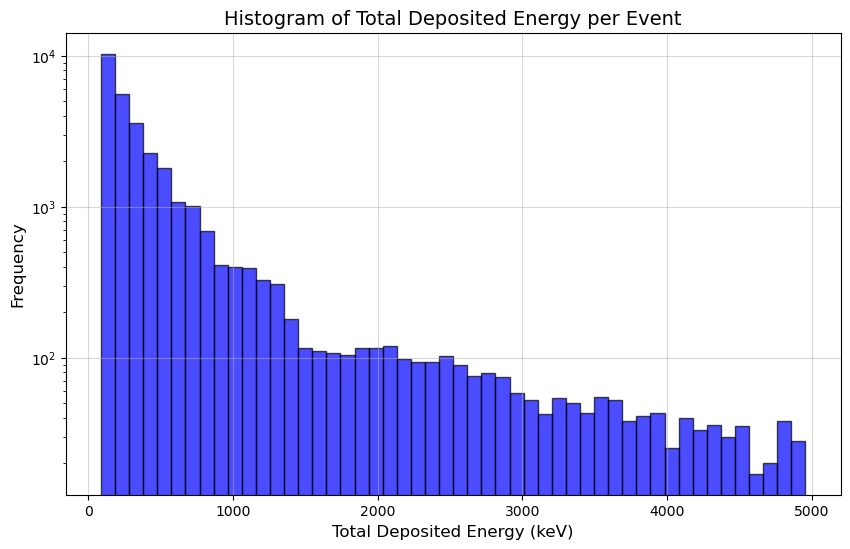

In [23]:
import matplotlib.pyplot as plt
# cut = (scaled_detector_hits['e_total']>=0)
# Calculate total deposited energy per event
scaled_detector_hits['e_total'] = scaled_detector_hits.groupby('event')['edep_scaled'].transform('sum')

# Plot histogram of e_total
plt.figure(figsize=(10, 6))
plt.hist(scaled_detector_hits['e_total'], bins=50, alpha=0.7, color='blue', edgecolor='black', log=True)
plt.xlabel('Total Deposited Energy (keV)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Total Deposited Energy per Event', fontsize=14)
plt.grid(alpha=0.5)
plt.show()


In [15]:
surface_charges = [-1.0, -0.7, -0.3, 0.0, 0.3, 0.7, 1.0]
# -1.5, -1.2, -1.1, 1.1, 1.2
# Prepare to store results for histogram
histogram_data = {}

# Iterate through each surface charge
for sc_value in tqdm(surface_charges):
    # print(f"Processing surface charge: {sc_value}")
    filter_sc = sc_value  # Update the filter for surface charge
    
    # Step 1: Adjust the activeness map
    adjusted_waveforms_df = adjust_activeness_map(waveforms_df)
    
    # Step 2: Interpolate the activeness map
    r_grid, z_grid, energy_interp_clipped = interpolate_activeness_map(adjusted_waveforms_df, grid_size=1000)
    
    # Step 3: Scale energy depositions with activeness
    scaled_detector_hits = scale_energy_with_activeness(proc_df.copy(), r_grid, z_grid, energy_interp_clipped)
    
    # Step 4: Compute total deposited energy per event
    scaled_detector_hits['e_total'] = scaled_detector_hits.groupby('event')['edep_scaled'].transform('sum')
    
    # Step 5: Store the e_total values for histogram
    histogram_data[sc_value] = scaled_detector_hits['e_total']

import pickle

# Save the data needed for plotting
save_path = "/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/eng_hist_plot_data.pkl"
plot_data = {
    "histogram_data": histogram_data,
    "surface_charges": surface_charges,
}

with open(save_path, "wb") as f:
    pickle.dump(plot_data, f)

print(f"Histogram data saved to {save_path}")


100%|██████████| 7/7 [03:10<00:00, 27.25s/it]

Histogram data saved to /nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/eng_hist_plot_data.pkl


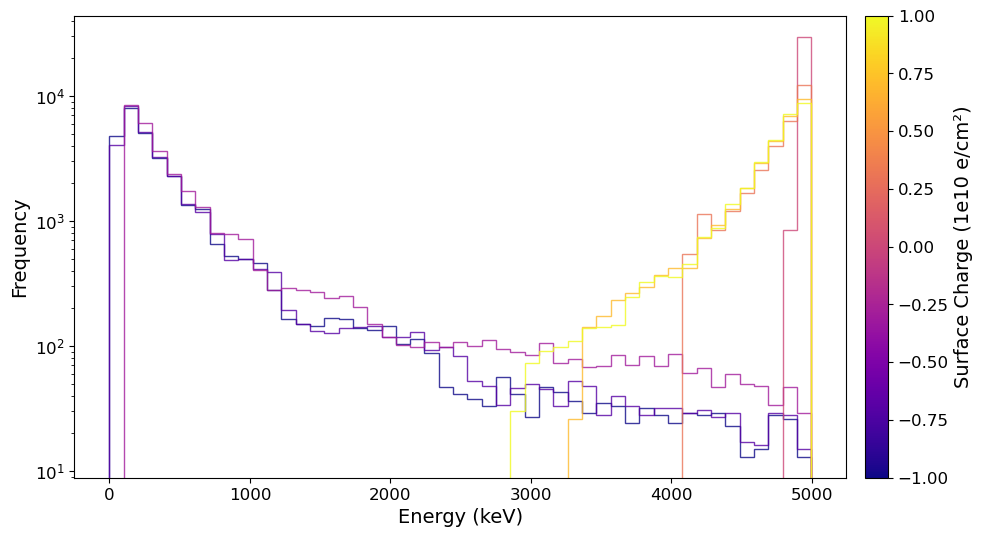

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cmx
import pickle
save_path = "/nas/longleaf/home/kbhimani/EH-Drift/Analysis/plot_data/eng_hist_plot_data.pkl"

# Load the data
with open(save_path, "rb") as f:
    loaded_data = pickle.load(f)

# Extract the data
loaded_histogram_data = loaded_data["histogram_data"]
loaded_surface_charges = loaded_data["surface_charges"]

# Reverse the colormap
cmap_plot = plt.colormaps.get_cmap('plasma')  # '_r' reverses the colormap

# Normalize surface charges for color mapping
norm = mcolors.Normalize(vmin=min(loaded_surface_charges), vmax=max(loaded_surface_charges))
colormap = cmx.ScalarMappable(norm=norm, cmap=cmap_plot)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Create bins for consistent histogram plotting
bins = np.linspace(0, max([max(loaded_histogram_data[sc]) for sc in loaded_histogram_data]), 50)

# Plot histograms with color gradient
for sc_value, e_total_values in loaded_histogram_data.items():
    color = colormap.to_rgba(sc_value)  # Map surface charge to color
    ax.hist(
        e_total_values, bins=bins, alpha=0.8, label=f"SC={sc_value:.1f}", log=True, histtype='step', color=color
    )

# Add a color bar for the surface charges
cbar = fig.colorbar(cmx.ScalarMappable(norm=norm, cmap=cmap_plot), ax=ax, pad=0.02)
cbar.set_label('Surface Charge (1e10 e/cm²)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Add labels, title, legend, and grid
ax.set_xlabel('Energy (keV)', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_title('Histograms of Total Deposited Energy per Event for Different Surface Charges', fontsize=16)
# ax.grid(alpha=0.5)
# ax.legend(title='Surface Charge (SC)', fontsize=10, loc='upper right', ncol=2)

# Show the plot
plt.show()